In [ ]:
import glob

files = glob.glob("*.xls") + glob.glob("*.csv")

print("Total files:", len(files))

for f in files:
    print(f)

Total files: 15
dataset_Imperialism_and_Colonialism.xls
dataset_Human_Crime_and_Justice.xls
dataset_Scientific_Discovery_and_Technology.xls
dataset_Class3_Scientific_Discovery_and_Technology_Charles_Dickens.xls
dataset_Class3_Class_Society_and_Social_Evolution_Charles_Dickens.xls
dataset_Class3_Human_Nature_and_Morality_Charles_Dickens.xls
dataset_Human_Human_Nature_and_Morality.xls
dataset_Human_Scientific_Discovery_and_Technology.xls
dataset_Human_Class_Society_and_Social_Evolution.xls
dataset_Class_Society_and_Social_Evolution.xls
dataset_Human_Imperialism_and_Colonialism.xls
dataset_Crime_and_Justice.xls
dataset_Human_Nature_and_Morality.xls
dataset_Class3_Crime_and_Justice_Charles_Dickens.xls
dataset_Class3_Imperialism_and_Colonialism_Charles_Dickens.xls


In [ ]:
import pandas as pd

for file in files:
    df = pd.read_csv(file)
    print(f"{file:<70} {len(df)} rows")

dataset_Imperialism_and_Colonialism.xls                                50 rows
dataset_Human_Crime_and_Justice.xls                                    50 rows
dataset_Scientific_Discovery_and_Technology.xls                        50 rows
dataset_Class3_Scientific_Discovery_and_Technology_Charles_Dickens.xls 50 rows
dataset_Class3_Class_Society_and_Social_Evolution_Charles_Dickens.xls  50 rows
dataset_Class3_Human_Nature_and_Morality_Charles_Dickens.xls           50 rows
dataset_Human_Human_Nature_and_Morality.xls                            50 rows
dataset_Human_Scientific_Discovery_and_Technology.xls                  50 rows
dataset_Human_Class_Society_and_Social_Evolution.xls                   50 rows
dataset_Class_Society_and_Social_Evolution.xls                         50 rows
dataset_Human_Imperialism_and_Colonialism.xls                          50 rows
dataset_Crime_and_Justice.xls                                          50 rows
dataset_Human_Nature_and_Morality.xls               

In [ ]:
import pandas as pd

frames = []

for file in files:
    df = pd.read_csv(file)
    frames.append(df)

dataset = pd.concat(frames, ignore_index=True)

print(dataset.shape)

(750, 3)


In [ ]:
print(dataset["Class"].value_counts())

Class
AI_Normal                      250
Human                          250
AI_Stylized_Charles_Dickens    250
Name: count, dtype: int64


In [ ]:
dataset.to_csv("final_dataset.csv", index=False)

print("Dataset Saved!")

Dataset Saved!


In [ ]:
dataset = dataset.sample(frac=1, random_state=42).reset_index(drop=True)

dataset.head()

,Topic,Paragraph,Class
0,Imperialism and Colonialism,“Quite so. I have a kind of intuition that way...,Human
1,Scientific Discovery and Technology,"We did not, however. Not a word came to us eit...",Human
2,Scientific Discovery and Technology,The intersection of scientific discovery and t...,AI_Normal
3,Human Nature and Morality,"It is a melancholy truth, oft repeated by the ...",AI_Stylized_Charles_Dickens
4,Human Nature and Morality,"Consider the soul of a man, that curious clock...",AI_Stylized_Charles_Dickens


In [ ]:
import nltk
import numpy as np
import pandas as pd
import spacy
import string

from collections import Counter
from sklearn.model_selection import train_test_split

In [ ]:
nlp = spacy.load("en_core_web_sm")

print("SpaCy Loaded Successfully")

SpaCy Loaded Successfully


In [ ]:
def extract_features(text):

    doc = nlp(text)

    words = [
        token.text.lower()
        for token in doc
        if token.is_alpha
    ]

    total_words = len(words)
    unique_words = len(set(words))

    ttr = unique_words / total_words if total_words else 0

    adjective_count = sum(token.pos_ == "ADJ" for token in doc)
    noun_count = sum(token.pos_ == "NOUN" for token in doc)

    adj_noun_ratio = adjective_count / noun_count if noun_count else 0

    punct_count = sum(ch in string.punctuation for ch in text)
    punctuation_density = punct_count / len(text) if len(text) else 0

    return pd.Series({
        "TTR": ttr,
        "Adj_Noun_Ratio": adj_noun_ratio,
        "Punctuation_Density": punctuation_density
    })

In [ ]:
features = dataset["Paragraph"].apply(extract_features)

print(features.head())

        TTR  Adj_Noun_Ratio  Punctuation_Density
0  0.712871        0.555556             0.022018
1  0.662577        0.333333             0.017998
2  0.807692        0.647059             0.010331
3  0.724832        0.538462             0.021348
4  0.650000        0.512195             0.015135


In [ ]:
dataset = pd.concat([dataset, features], axis=1)

dataset.head()

,Topic,Paragraph,Class,TTR,Adj_Noun_Ratio,Punctuation_Density
0,Imperialism and Colonialism,“Quite so. I have a kind of intuition that way...,Human,0.712871,0.555556,0.022018
1,Scientific Discovery and Technology,"We did not, however. Not a word came to us eit...",Human,0.662577,0.333333,0.017998
2,Scientific Discovery and Technology,The intersection of scientific discovery and t...,AI_Normal,0.807692,0.647059,0.010331
3,Human Nature and Morality,"It is a melancholy truth, oft repeated by the ...",AI_Stylized_Charles_Dickens,0.724832,0.538462,0.021348
4,Human Nature and Morality,"Consider the soul of a man, that curious clock...",AI_Stylized_Charles_Dickens,0.650000,0.512195,0.015135


In [19]:
from sklearn.preprocessing import LabelEncoder

X = dataset[["TTR", "Adj_Noun_Ratio", "Punctuation_Density"]]

y = dataset["Class"]

encoder = LabelEncoder()
y = encoder.fit_transform(y)

print(X.head())
print(y[:5])

        TTR  Adj_Noun_Ratio  Punctuation_Density
0  0.712871        0.555556             0.022018
1  0.662577        0.333333             0.017998
2  0.807692        0.647059             0.010331
3  0.724832        0.538462             0.021348
4  0.650000        0.512195             0.015135
[2 2 0 1 1]


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [21]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [22]:
pred = rf.predict(X_test)

In [23]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, pred)

print("Accuracy:", accuracy)

Accuracy: 0.8


In [24]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, pred))

print(confusion_matrix(y_test, pred))

              precision    recall  f1-score   support

           0       0.88      0.74      0.80        50
           1       0.71      0.82      0.76        50
           2       0.84      0.84      0.84        50

    accuracy                           0.80       150
   macro avg       0.81      0.80      0.80       150
weighted avg       0.81      0.80      0.80       150

[[37 10  3]
 [ 4 41  5]
 [ 1  7 42]]


In [25]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
0,TTR,0.403821
2,Punctuation_Density,0.352002
1,Adj_Noun_Ratio,0.244177


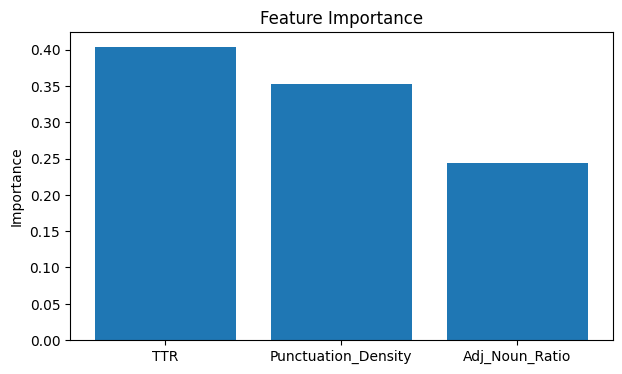

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Feature Importance")
plt.ylabel("Importance")

plt.show()